# Results and Paper Figures

**Objective:** Read all raw CSVs produced by experiments 1 and 2, compute
final metrics, and generate publication-ready Table I and Figure 1.

This notebook does **not** run any inference — it is a pure post-processing
and visualisation step and can be run on any machine that has the CSVs.

**Sequences (methodology v2):** All three static-camera MOT17 sequences spanning
pedestrian density and camera geometry:
- MOT17-09: sparse (10.1 ped/fr), pedestrian street, daytime, low angle
- MOT17-02: moderate (31.0 ped/fr), open square, moderate elevation
- MOT17-04: dense (45.3 ped/fr), pedestrian street, nighttime, elevated viewpoint

Sequences differ simultaneously in density and elevation; these variables cannot
be fully decoupled within the available MOT17 static-camera sequences.

**IEEE two-column figure conventions used:**
- Single-column width: 3.5 in
- Two-column width: 7.16 in
- Body font: 10pt (matplotlib equivalent: `fontsize=10`)
- Line width: 0.8 pt for thin lines, 1.2 pt for data curves

In [1]:
# Configuration
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from benchmark.config import (
    DATA_ROOT, RESULTS_RAW, SEQUENCES, SEQ_SUFFIX,
    MODEL_VARIANTS, RESOLUTIONS, IMGSZ_BASE,
)
from benchmark.metrics import compute_mot_metrics
from benchmark.degradation import detection_stability, track_continuity, spatial_precision

FIGURES_DIR  = RESULTS_RAW.parent / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# IEEE-compatible rcParams
matplotlib.rcParams.update({
    "font.size":       10,
    "axes.titlesize":  10,
    "axes.labelsize":  10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "lines.linewidth": 1.2,
    "axes.linewidth":  0.8,
})

In [2]:
# ── Table I: Experiment 1 profiling matrix ──
# Reads all Exp1 CSVs and computes timing + MOT metrics per (model, seq).

table_rows = []

for model_path in MODEL_VARIANTS:
    for seq_name in SEQUENCES:
        csv_path = RESULTS_RAW / f"{seq_name}_{model_path}_{IMGSZ_BASE}.csv"
        if not csv_path.exists():
            continue

        df       = pd.read_csv(csv_path)
        seq_dir  = DATA_ROOT / f"{seq_name}-{SEQ_SUFFIX}"
        m        = compute_mot_metrics(csv_path, seq_dir)

        t        = df["inference_ms"].dropna()
        table_rows.append({
            "Model":     model_path.replace(".pt", ""),
            "Sequence":  seq_name,
            "FPS":       round(1000 / t.median(), 1),
            "Med ms":    round(t.median(), 1),
            "P95 ms":    round(t.quantile(0.95), 1),
            "Mem MB":    round(df["mem_bytes"].max() / 1e6, 1),
            "MOTA":      round(m["mota"], 3),
            "IDF1":      round(m["idf1"], 3),
            "IDSW":      m["num_switches"],
            "IDSW/GT":   round(m["idsw_per_gt_track"], 3),
            "Frag":      round(m["frag_ratio"], 3),
        })

table1 = pd.DataFrame(table_rows).set_index(["Model", "Sequence"])
print("Table I — Device × Model Profiling")
print(table1.to_string())

table1.to_csv(FIGURES_DIR / "table1_profiling.csv")
print(f"\nSaved: {FIGURES_DIR / 'table1_profiling.csv'}")

Table I — Device × Model Profiling
                    FPS  Med ms  P95 ms  Mem MB   MOTA   IDF1  IDSW  IDSW/GT   Frag
Model   Sequence                                                                   
yolo26n MOT17-09  227.8     4.4     4.9    68.5  0.548  0.572    47    1.808  0.115
        MOT17-02  223.0     4.5     5.0    77.6  0.305  0.429    45    0.849  0.075
        MOT17-04  219.1     4.6     5.1    87.3  0.252  0.359    56    0.709  0.139
yolo26s MOT17-09  210.7     4.7     5.3  1665.3  0.567  0.566    37    1.423  0.000
        MOT17-02  216.1     4.6     5.2  1707.9  0.336  0.529    40    0.755  0.170
        MOT17-04  204.4     4.9     5.5  1711.8  0.321  0.441    46    0.582  0.101
yolo26m MOT17-09  156.2     6.4     6.6  1679.2  0.563  0.586    26    1.000  0.077
        MOT17-02  153.8     6.5     6.8  1717.3  0.411  0.542    41    0.774  0.132
        MOT17-04  152.2     6.6     6.8  1725.6  0.294  0.425    42    0.532  0.089
yolo26l MOT17-09  126.9     7.9     8.2  

In [3]:
# ── Determine selected model per device (Exp1 → Exp2 handoff) ──
# Highest mean FPS across sequences, constrained to models with non-trivial tracking.

fps_summary = (
    table1.reset_index()
    .groupby("Model")["FPS"].mean()
    .sort_values(ascending=False)
)

SELECTED_MODEL = fps_summary.idxmax() + ".pt"
print(f"Selected model for Exp2: {SELECTED_MODEL}")
print(fps_summary)

Selected model for Exp2: yolo26n.pt
Model
yolo26n    223.300000
yolo26s    210.400000
yolo26m    154.066667
yolo26l    125.900000
yolo26x     78.700000
Name: FPS, dtype: float64


In [4]:
# ── Exp2 degradation signal matrix ──
# Include all three track continuity signals to capture failure-mode transition.

deg_rows = []

for seq_name in SEQUENCES:
    baseline_csv = RESULTS_RAW / f"{seq_name}_{SELECTED_MODEL}_{IMGSZ_BASE}.csv"
    seq_dir      = DATA_ROOT / f"{seq_name}-{SEQ_SUFFIX}"
    if not baseline_csv.exists():
        continue

    for imgsz in RESOLUTIONS:
        csv_path = RESULTS_RAW / f"{seq_name}_{SELECTED_MODEL}_{imgsz}.csv"
        if not csv_path.exists():
            continue
        ds = detection_stability(csv_path, baseline_csv)
        tc = track_continuity(csv_path, seq_dir)
        sp = spatial_precision(csv_path, baseline_csv)
        deg_rows.append({
            "seq":                  seq_name,
            "imgsz":                imgsz,
            "det_stability":        ds,
            "num_switches":         tc["num_switches"],
            "idsw_per_gt_track":    tc["idsw_per_gt_track"],
            "frag_ratio":           tc["frag_ratio"],
            "mostly_tracked_ratio": tc["mostly_tracked_ratio"],
            "spatial_prec":         sp,
        })

deg_df = pd.DataFrame(deg_rows)

# Per-sequence normalisation anchored at 640 baseline.
for seq_name in SEQUENCES:
    mask     = deg_df["seq"] == seq_name
    baseline = deg_df[mask & (deg_df["imgsz"] == IMGSZ_BASE)]
    if baseline.empty:
        continue

    base_idsw  = float(baseline["idsw_per_gt_track"].iloc[0])
    base_frag  = float(baseline["frag_ratio"].iloc[0])
    base_mt    = float(baseline["mostly_tracked_ratio"].iloc[0])
    peak_det   = deg_df.loc[mask, "det_stability"].max()
    peak_sp    = deg_df.loc[mask, "spatial_prec"].max()

    deg_df.loc[mask, "det_stability_norm"] = (
        deg_df.loc[mask, "det_stability"] / peak_det if peak_det > 0 else 0.0
    )
    deg_df.loc[mask, "spatial_prec_norm"] = (
        deg_df.loc[mask, "spatial_prec"] / peak_sp if peak_sp > 0 else 0.0
    )
    deg_df.loc[mask, "idsw_delta_norm"] = (
        (deg_df.loc[mask, "idsw_per_gt_track"] - base_idsw) / base_idsw
    ).clip(-1, None) if base_idsw > 0 else 0.0
    deg_df.loc[mask, "frag_delta_norm"] = (
        (deg_df.loc[mask, "frag_ratio"] - base_frag) / base_frag
    ).clip(-1, None) if base_frag > 0 else 0.0
    deg_df.loc[mask, "mt_delta_norm"] = (
        (base_mt - deg_df.loc[mask, "mostly_tracked_ratio"]) / base_mt
    ).clip(-1, None) if base_mt > 0 else 0.0

Saved: /home/joaocarlos/Developer/yolo26-track-edge-benchmark/results/figures/fig1_degradation.pdf
Saved: /home/joaocarlos/Developer/yolo26-track-edge-benchmark/results/figures/fig1_degradation.png


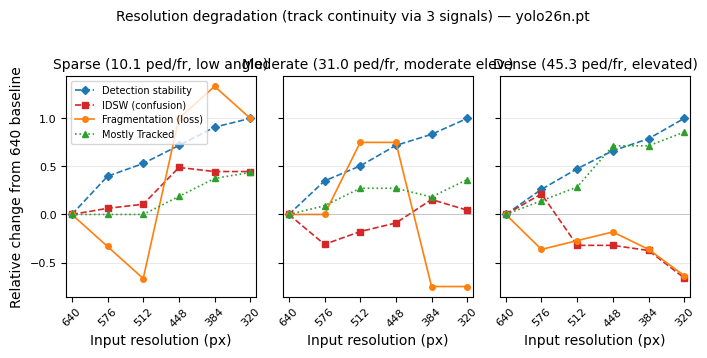

In [5]:
# ── Figure 1: Track continuity degradation curves (IEEE two-column, 7.16 in) ──
#
# Key insight: IDSW alone is insufficient. The three signals reveal a failure-mode
# transition in MOT17-04 (dense):
# - IDSW decreases (fewer confusion events) as resolution drops
# - Fragmentation increases (more track loss) as resolution drops
# This is not contradictory — it's the transition from confusion-dominated (640px)
# to loss-dominated (320px) failure regimes.
#
# MOT17-09 (low-angle, sparse) and MOT17-02 (moderate elevation) provide supporting
# characterisation; differences across sequences reflect both density and geometry.

SEQ_LABELS = {
    "MOT17-09": "Sparse (10.1 ped/fr, low angle)",
    "MOT17-02": "Moderate (31.0 ped/fr, moderate elev.)",
    "MOT17-04": "Dense (45.3 ped/fr, elevated)",
}

COLORS = {
    "det_stability_norm": "#1f77b4",
    "idsw_delta_norm":    "#d62728",
    "frag_delta_norm":    "#ff7f0e",
    "mt_delta_norm":      "#2ca02c",
}
LABELS = {
    "det_stability_norm": "Detection stability",
    "idsw_delta_norm":    "IDSW (confusion)",
    "frag_delta_norm":    "Fragmentation (loss)",
    "mt_delta_norm":      "Mostly Tracked",
}
STYLES = {
    "det_stability_norm": "D--",
    "idsw_delta_norm":    "s--",
    "frag_delta_norm":    "o-",
    "mt_delta_norm":      "^:",
}

fig, axes = plt.subplots(1, 3, figsize=(7.16, 3.5), sharey=True)

for ax, seq_name in zip(axes, SEQUENCES):
    sub = deg_df[deg_df["seq"] == seq_name].sort_values("imgsz", ascending=False)
    ax.plot(sub["imgsz"], sub["det_stability_norm"],
            STYLES["det_stability_norm"], color=COLORS["det_stability_norm"],
            label=LABELS["det_stability_norm"], markersize=4)
    for col in ["idsw_delta_norm", "frag_delta_norm", "mt_delta_norm"]:
        ax.plot(sub["imgsz"], sub[col], STYLES[col], color=COLORS[col],
                label=LABELS[col], markersize=4)

    ax.axhline(0, color="grey", linewidth=0.6, linestyle="-", alpha=0.4)
    ax.set_xlabel("Input resolution (px)")
    ax.set_title(SEQ_LABELS.get(seq_name, seq_name))
    ax.set_xlim(650, 310)
    ax.set_xticks(RESOLUTIONS)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linewidth=0.4, alpha=0.5)

axes[0].set_ylabel("Relative change from 640 baseline")
axes[0].legend(loc="upper left", fontsize=7)

fig.suptitle(f"Resolution degradation (track continuity via 3 signals) — {SELECTED_MODEL}",
             fontsize=10, y=1.01)
plt.tight_layout()

pdf_path = FIGURES_DIR / "fig1_degradation.pdf"
png_path = FIGURES_DIR / "fig1_degradation.png"
fig.savefig(pdf_path, bbox_inches="tight", dpi=300)
fig.savefig(png_path, bbox_inches="tight", dpi=300)
print(f"Saved: {pdf_path}")
print(f"Saved: {png_path}")
plt.show()

In [6]:
# ── Operating envelope summary ──
# First resolution at which each signal exceeds a 10% relative change from the 640 baseline.
# "Knee" = highest resolution at which signal crosses the threshold (onset of degradation).
# Note: IDSW may decrease in dense scenes as resolution drops (confusion→loss transition);
# in such cases the IDSW knee is not applicable and is reported as "N/A (non-monotone)".

print("Operating envelope per sequence (threshold: >10% relative change from 640 baseline):")
print()

for seq_name in SEQUENCES:
    sub = deg_df[deg_df["seq"] == seq_name].sort_values("imgsz", ascending=False)

    base_row = sub[sub["imgsz"] == IMGSZ_BASE]
    if base_row.empty:
        continue

    base_idsw = float(base_row["idsw_per_gt_track"].iloc[0])
    seq_label = SEQ_LABELS.get(seq_name, seq_name)
    print(f"  {seq_name}  [{seq_label}]")
    print(f"    Baseline IDSW/GT-track at 640px: {base_idsw:.3f}")

    # Detection stability: first resolution where det_stability_norm > 0.1
    ds_exceed = sub[sub["det_stability_norm"] > 0.1]
    ds_knee   = int(ds_exceed["imgsz"].max()) if not ds_exceed.empty else None

    # IDSW: first resolution where delta > +10% (monotone check: report if non-monotone)
    idsw_exceed = sub[sub["idsw_delta_norm"] > 0.1]
    idsw_knee   = int(idsw_exceed["imgsz"].max()) if not idsw_exceed.empty else None
    idsw_is_nonmonotone = bool((sub["idsw_delta_norm"] < -0.1).any())

    # Fragmentation: first resolution where frag_delta_norm > 0.1
    frag_exceed = sub[sub["frag_delta_norm"] > 0.1]
    frag_knee   = int(frag_exceed["imgsz"].max()) if not frag_exceed.empty else None

    # MT ratio: first resolution where mt_delta_norm > 0.1 (MT dropped > 10%)
    mt_exceed = sub[sub["mt_delta_norm"] > 0.1]
    mt_knee   = int(mt_exceed["imgsz"].max()) if not mt_exceed.empty else None

    for label, knee, note in [
        ("Detection stability", ds_knee, ""),
        ("IDSW/GT-track (+10%)", idsw_knee,
         " [non-monotone: confusion→loss transition]" if idsw_is_nonmonotone else ""),
        ("Fragmentation (+10%)", frag_knee, ""),
        ("Mostly Tracked (−10%)", mt_knee, ""),
    ]:
        if knee:
            print(f"    {label:28s}: first degrades at {knee}px{note}")
        else:
            print(f"    {label:28s}: no >10% change detected{note}")
    print()

Operating envelope per sequence (threshold: >10% relative change from 640 baseline):

  MOT17-09  [Sparse (10.1 ped/fr, low angle)]
    Baseline IDSW/GT-track at 640px: 1.808
    Detection stability         : first degrades at 576px
    IDSW/GT-track (+10%)        : first degrades at 512px
    Fragmentation (+10%)        : first degrades at 448px
    Mostly Tracked (−10%)       : first degrades at 448px

  MOT17-02  [Moderate (31.0 ped/fr, moderate elev.)]
    Baseline IDSW/GT-track at 640px: 0.849
    Detection stability         : first degrades at 576px
    IDSW/GT-track (+10%)        : first degrades at 384px [non-monotone: confusion→loss transition]
    Fragmentation (+10%)        : first degrades at 512px
    Mostly Tracked (−10%)       : first degrades at 512px

  MOT17-04  [Dense (45.3 ped/fr, elevated)]
    Baseline IDSW/GT-track at 640px: 0.709
    Detection stability         : first degrades at 576px
    IDSW/GT-track (+10%)        : first degrades at 576px [non-monotone: con

## Results

- Table I saved to `results/figures/table1_profiling.csv`
- Figure 1 saved to `results/figures/fig1_degradation.{pdf,png}`
- Operating envelope per sequence: *(see cell above after full runs)*

## Next steps

- Add power consumption column to Table I (from manual USB-meter measurements).
- Repeat figure generation per device once all edge-device CSVs are copied.
- Write Discussion section using the operating envelope summary above.